In [1]:
# 1. Set the legacy Keras flag BEFORE any other libraries are loaded
import os
os.environ['TF_USE_LEGACY_KERAS'] = '1'

# 2. Install a rock-solid, TF-compatible version of Transformers along with required packages
!pip install -q "transformers==4.38.2" datasets tf-keras seaborn

# 3. Now perform the imports
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification
from datasets import load_dataset
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np
import matplotlib.pyplot as plt

print(f"TensorFlow version: {tf.__version__}")
print("Success: TFAutoModelForSequenceClassification imported perfectly!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 130.7/130.7 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.5/8.5 MB 67.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 37.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 84.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.3.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.38.2 which is incompatible.
TensorFlow version: 2.19.0
Success: TFAutoModelForSequenceClassification imported perfectly!


In [2]:
print("Loading IMDB dataset from Hugging Face...")
imdb_dataset = load_dataset("imdb")
print("Dataset loaded successfully!")

Loading IMDB dataset from Hugging Face...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Dataset loaded successfully!


In [3]:
MODEL_NAME = "roberta-base"

print(f"Loading tokenizer for '{MODEL_NAME}'...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print("Tokenizer loaded.")

Loading tokenizer for 'roberta-base'...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/481 [00:00<?, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded.


In [4]:
def tokenize_function(examples):
    # Padding and truncation ensure uniform input size
    return tokenizer(examples["text"], padding="max_length", truncation=True, max_length=128)

print("Tokenizing the dataset (this will take a few moments)...")
tokenized_datasets = imdb_dataset.map(tokenize_function, batched=True)
print("Tokenization complete.")

Tokenizing the dataset (this will take a few moments)...


Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/25000 [00:00<?, ? examples/s]

Map:   0%|          | 0/50000 [00:00<?, ? examples/s]

Tokenization complete.


In [5]:
BATCH_SIZE = 16
print("Converting datasets to tf.data.Dataset format...")

# Train set
tf_train_dataset = tokenized_datasets["train"].to_tf_dataset(
    columns=["attention_mask", "input_ids"],
    label_cols=["label"],
    shuffle=True,
    batch_size=BATCH_SIZE
)

# Test set
tf_test_dataset = tokenized_datasets["test"].to_tf_dataset(
    columns=["attention_mask", "input_ids"],
    label_cols=["label"],
    shuffle=False,
    batch_size=BATCH_SIZE
)

# Extract true labels for evaluation later
y_test = np.array(tokenized_datasets["test"]["label"])
print("Conversion complete.")

Converting datasets to tf.data.Dataset format...


/usr/local/lib/python3.12/dist-packages/datasets/arrow_dataset.py:403: FutureWarning: The output of `to_tf_dataset` will change when a passing single element list for `labels` or `columns` in the next datasets version. To return a tuple structure rather than dict, pass a single string.
Old behaviour: columns=['a'], labels=['labels'] -> (tf.Tensor, tf.Tensor)  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor)  
New behaviour: columns=['a'],labels=['labels'] -> ({'a': tf.Tensor}, {'labels': tf.Tensor})  
             : columns='a', labels='labels' -> (tf.Tensor, tf.Tensor) 
  warnings.warn(


Conversion complete.


In [6]:
from transformers import TFAutoModelForSequenceClassification

MODEL_NAME = "roberta-base"

model = TFAutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/499M [00:00<?, ?B/s]

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFRobertaForSequenceClassification: ['roberta.embeddings.position_ids']
- This IS expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFRobertaForSequenceClassification from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
Some weights or buffers of the TF 2.0 model TFRobertaForSequenceClassification were not initialized from the PyTorch model and are newly initialized: ['classifier.dense.weight', 'classifier.dense.bias', 'classifier.out_proj.weight', 'classifier.out_proj.bias']
You should probably TRAIN this model on a down-stream task to be able to use it for predicti

In [7]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import SparseCategoricalCrossentropy
from tensorflow.keras.callbacks import EarlyStopping

NUM_EPOCHS = 2  # keep small for Colab

model.compile(
    optimizer=Adam(learning_rate=3e-5),
    loss=SparseCategoricalCrossentropy(from_logits=True),
    metrics=["accuracy"]
)

early_stopping_cb = EarlyStopping(
    monitor="val_loss",
    patience=1,
    restore_best_weights=True
)

history = model.fit(
    tf_train_dataset,
    validation_data=tf_test_dataset,
    epochs=NUM_EPOCHS,
    callbacks=[early_stopping_cb]
)

Epoch 1/2
1563/1563 [==============================] - 996s 593ms/step - loss: 0.3125 - accuracy: 0.8674 - val_loss: 0.2440 - val_accuracy: 0.9034
Epoch 2/2
1563/1563 [==============================] - 900s 576ms/step - loss: 0.2147 - accuracy: 0.9153 - val_loss: 0.2656 - val_accuracy: 0.8961


In [8]:
# This will trigger a Colab popup asking for Drive access permissions
print("Connecting to Google Drive...")
from google.colab import drive
drive.mount('/content/drive')

save_path = "/content/drive/MyDrive/projectCodes/text_roberta_model"

model.save_pretrained(save_path)
tokenizer.save_pretrained(save_path)
print("Model and tokenizer saved successfully!")

Connecting to Google Drive...
Mounted at /content/drive
Model and tokenizer saved successfully!


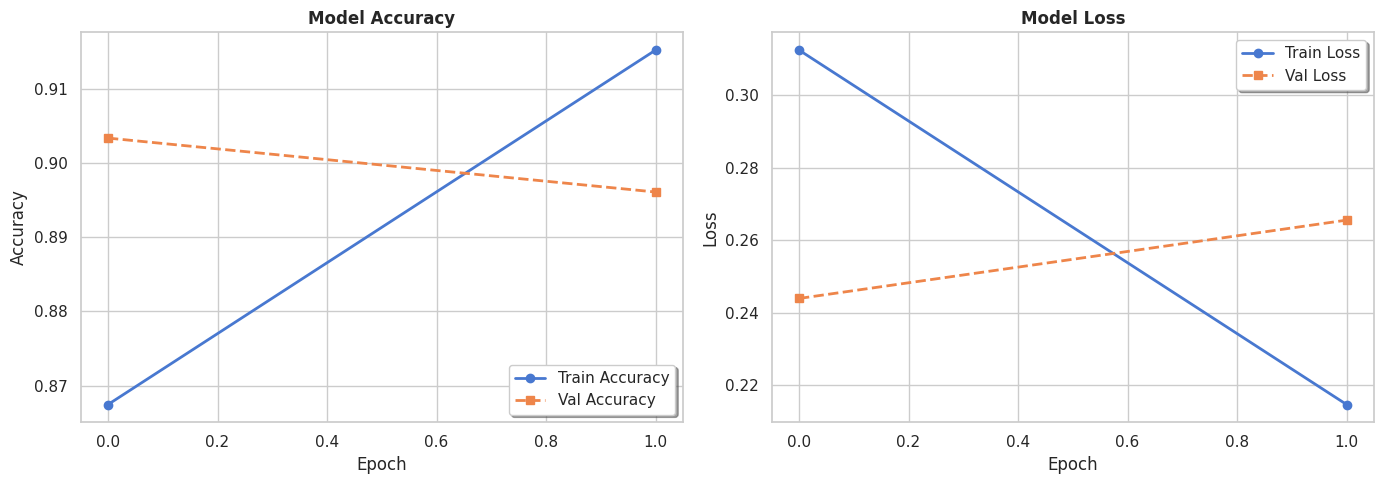

In [9]:
def plot_history(history):
    # Professional styling
    sns.set_theme(style="whitegrid", palette="muted")
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # --- Plot Accuracy ---
    ax1.plot(history.history['accuracy'], label='Train Accuracy', marker='o', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Val Accuracy', marker='s', linestyle='--', linewidth=2)
    ax1.set_title('Model Accuracy', fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend(loc='lower right', shadow=True)

    # --- Plot Loss ---
    ax2.plot(history.history['loss'], label='Train Loss', marker='o', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Val Loss', marker='s', linestyle='--', linewidth=2)
    ax2.set_title('Model Loss', fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend(loc='upper right', shadow=True)

    plt.tight_layout()
    plt.show()

plot_history(history)

Evaluating model...
1563/1563 [==============================] - 238s 152ms/step - loss: 0.2440 - accuracy: 0.9034
Test Loss: 0.2440 | Test Accuracy: 0.9034

1563/1563 [==============================] - 239s 151ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.92      0.89      0.90     12500
    Positive       0.89      0.92      0.91     12500

    accuracy                           0.90     25000
   macro avg       0.90      0.90      0.90     25000
weighted avg       0.90      0.90      0.90     25000



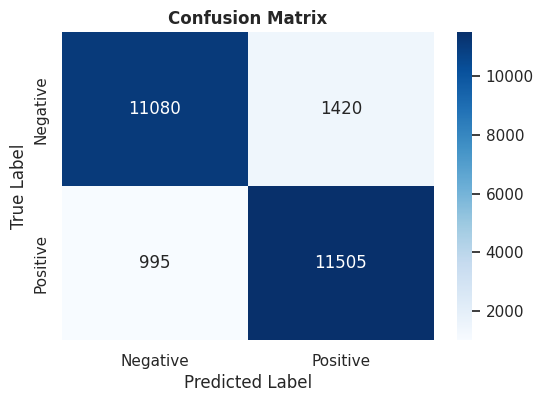

In [10]:
print("Evaluating model...")
eval_loss, eval_acc = model.evaluate(tf_test_dataset)
print(f"Test Loss: {eval_loss:.4f} | Test Accuracy: {eval_acc:.4f}\n")

# Get predictions
predictions = model.predict(tf_test_dataset)
y_pred = np.argmax(predictions.logits, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Plot Confusion Matrix cleanly
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix', fontweight='bold')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

Generating word clouds...


Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

Filter:   0%|          | 0/25000 [00:00<?, ? examples/s]

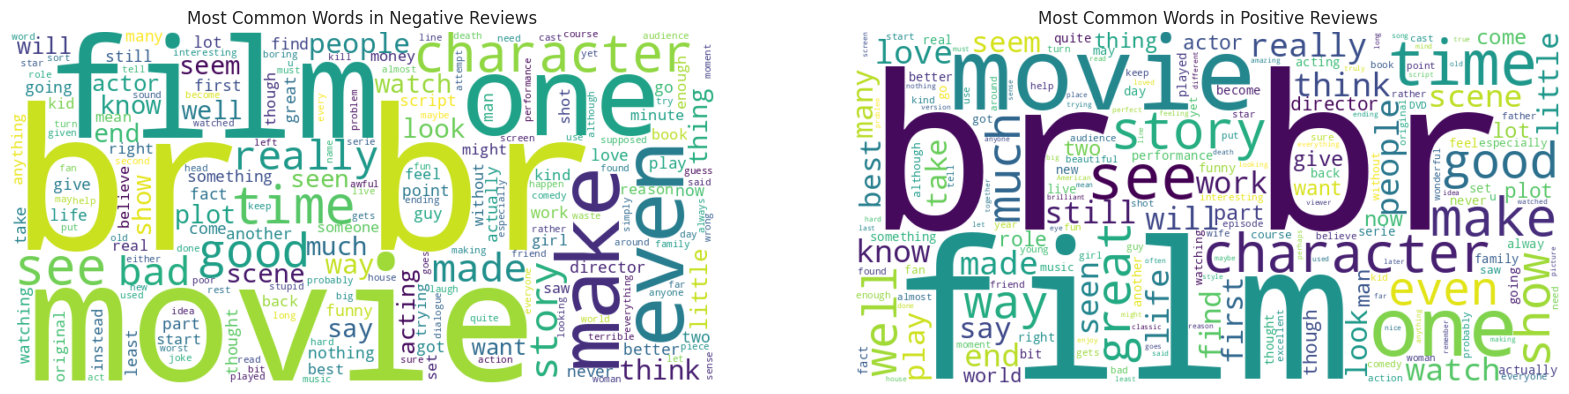

In [11]:
# FIX: Install and import the wordcloud library
!pip install wordcloud -q
from wordcloud import WordCloud

# We need to re-create the text lists from the Hugging Face dataset
print("Generating word clouds...")
negative_reviews = " ".join(imdb_dataset['train'].filter(lambda x: x['label'] == 0)['text'])
positive_reviews = " ".join(imdb_dataset['train'].filter(lambda x: x['label'] == 1)['text'])

# Create Word Clouds
wc_negative = WordCloud(width=800, height=400, background_color='white').generate(negative_reviews)
wc_positive = WordCloud(width=800, height=400, background_color='white').generate(positive_reviews)

# Plot the word clouds
plt.figure(figsize=(20, 10))
plt.subplot(1, 2, 1)
plt.imshow(wc_negative, interpolation='bilinear')
plt.title('Most Common Words in Negative Reviews')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wc_positive, interpolation='bilinear')
plt.title('Most Common Words in Positive Reviews')
plt.axis('off')

plt.show()

In [12]:
def predict_sentiment(review_text):
    inputs = tokenizer(review_text, return_tensors="tf", truncation=True, padding=True, max_length=128)
    outputs = model(**inputs)

    # Convert logits to probabilities
    probs = tf.nn.softmax(outputs.logits, axis=1).numpy()[0]
    pred_class = np.argmax(probs)

    sentiment = "Positive" if pred_class == 1 else "Negative"
    print(f"Review: '{review_text}'")
    print(f"Predicted Sentiment: {sentiment} (Confidence: {probs[pred_class]*100:.2f}%)\n" + "-"*30)

# Test array
reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot was gripping.",
    "I was really bored. The story was predictable and it felt way too long.",
    "The film was okay. Not the best I've seen, but it had some good moments."
]

for r in reviews:
    predict_sentiment(r)

Review: 'This movie was absolutely fantastic! The acting was superb and the plot was gripping.'
Predicted Sentiment: Positive (Confidence: 99.53%)
------------------------------
Review: 'I was really bored. The story was predictable and it felt way too long.'
Predicted Sentiment: Negative (Confidence: 97.74%)
------------------------------
Review: 'The film was okay. Not the best I've seen, but it had some good moments.'
Predicted Sentiment: Negative (Confidence: 59.49%)
------------------------------


In [13]:
# Cell 13: Testing Custom Reviews

def predict_sentiment(review_text):
    """
    Updated function that returns the sentiment and confidence
    values instead of just printing them.
    """
    inputs = tokenizer(review_text, return_tensors="tf", truncation=True, padding=True, max_length=128)
    outputs = model(**inputs)

    # Calculate probabilities
    probs = tf.nn.softmax(outputs.logits, axis=1).numpy()[0]
    pred_class = np.argmax(probs)

    sentiment = "Positive" if pred_class == 1 else "Negative"
    confidence = probs[pred_class] * 100

    return sentiment, confidence

# Store your reviews in a list for cleaner code execution
my_reviews = [
    "This movie was absolutely fantastic! The acting was superb and the plot was gripping.",
    "I was really bored. The story was predictable and it felt way too long. I would not recommend this.",
    "The film was okay. Not the best I've seen, but it had some good moments."
]

print("Running Custom Inference...\n" + "="*40)

# Loop through each review dynamically
for i, review in enumerate(my_reviews, 1):
    sentiment, confidence = predict_sentiment(review)

    print(f"Test Review {i}:")
    print(f"Text: '{review}'")
    print(f"Predicted Sentiment: {sentiment} (Confidence: {confidence:.2f}%)")
    print("-" * 40)

Running Custom Inference...
Test Review 1:
Text: 'This movie was absolutely fantastic! The acting was superb and the plot was gripping.'
Predicted Sentiment: Positive (Confidence: 99.53%)
----------------------------------------
Test Review 2:
Text: 'I was really bored. The story was predictable and it felt way too long. I would not recommend this.'
Predicted Sentiment: Negative (Confidence: 97.84%)
----------------------------------------
Test Review 3:
Text: 'The film was okay. Not the best I've seen, but it had some good moments.'
Predicted Sentiment: Negative (Confidence: 59.49%)
----------------------------------------


In [ ]:
# loss, accuracy = model.evaluate(tf_test_dataset)
# print(f"Test Accuracy: {accuracy}")

In [14]:
import tensorflow as tf
from transformers import AutoTokenizer, TFAutoModelForSequenceClassification

# load from saved path (IMPORTANT for reuse)
MODEL_PATH = "/content/drive/MyDrive/projectCodes/text_roberta_model"

tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
model = TFAutoModelForSequenceClassification.from_pretrained(MODEL_PATH)

def predict_sentiment(text):
    inputs = tokenizer(
        text,
        return_tensors="tf",
        truncation=True,
        padding=True,
        max_length=512
    )

    outputs = model(inputs)
    logits = outputs.logits

    predicted_class_id = tf.argmax(logits, axis=1).numpy()[0]

    return "Positive" if predicted_class_id == 1 else "Negative"

All model checkpoint layers were used when initializing TFRobertaForSequenceClassification.

All the layers of TFRobertaForSequenceClassification were initialized from the model checkpoint at /content/drive/MyDrive/projectCodes/text_roberta_model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFRobertaForSequenceClassification for predictions without further training.
